# Add catchment selection criteria to metadata

Add criteria to decide if a gauge should be published in CAMELS-DE-1h or left out.  

**Criteria**:
* Percentage of catchment area inside Germany -> `area_pct_in_germany`
* Difference of catchment area calculated from MERIT Hydro to area information from data providers -> `diff_to_reported_area`
* Discharge and water level years available -> `q_years`, `w_years`

**Additional additions to metadata**:
* Catchment already part of CAMELS-DE-1d -> `in_camels_de1d`
* Area calculated form MERIT Hydro catchment -> `area_calc`

In [1]:
import geopandas as gpd
import polars as pl
import matplotlib.pyplot as plt
from tqdm import tqdm

from camels_de1h import get_metadata1h, Station1h

In [2]:
# set to True if criteria are already added to metadata1h.csv, possible to only plot then
PLOT_ONLY = True

Read data

In [3]:
meta1h = get_metadata1h()

meta1h

,gauge_id,provider_id,gauge_name,waterbody_name,federal_state,lon,lat,easting,northing,elev_metadata,area_metadata,part_of_camelsp,area_calc,in_camelsde_1d,area_pct_in_germany,q_years,w_years,diff_to_reported_area
0,DE110000,105,Kirchen-Hausen,Donau,Baden-Württemberg,8.679586,47.925507,4.222273e+06,2.757761e+06,657.334,758.528,True,763.066361,True,100.0,24.00,24.0,0.598312
1,DE110010,106,Möhringen,Donau,Baden-Württemberg,8.760112,47.948961,4.228336e+06,2.760263e+06,649.162,826.963,True,831.294102,True,100.0,23.16,24.0,0.523736
2,DE110020,120,Hundersingen,Donau,Baden-Württemberg,9.396100,48.072462,4.275974e+06,2.773394e+06,542.530,2621.324,True,2618.597245,True,100.0,24.00,24.0,-0.104022
3,DE110030,125,Berg,Donau,Baden-Württemberg,9.731457,48.266270,4.301054e+06,2.794786e+06,489.903,4072.790,True,4093.963291,True,100.0,24.00,24.0,0.519872
4,DE110040,129,Achstetten,Baierzer Rot,Baden-Württemberg,9.900817,48.263440,4.313633e+06,2.794441e+06,489.317,264.393,True,272.811527,True,100.0,24.00,24.0,3.184096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2009,DEG11350,577340,Hohenleuben (ZP),Leuba,Thüringen,12.076081,50.703843,4.467645e+06,3.067877e+06,305.536,28.200,False,28.552454,False,100.0,11.92,0.0,1.249837
2010,DEG11360,577342,Hohenleuben (AP),Leuba,Thüringen,12.068883,50.724615,4.467072e+06,3.070172e+06,279.136,41.400,False,42.110346,False,100.0,8.84,0.0,1.715811
2011,DEG11370,577343,Hohenölsen,Ölsengrund,Thüringen,12.067612,50.725548,4.466979e+06,3.070273e+06,280.546,3.600,False,45.999463,False,100.0,12.00,0.0,1177.762847
2012,DEG11380,577350,Weida-Heinoldsmühle,Auma,Thüringen,12.015941,50.768096,4.463203e+06,3.074903e+06,271.878,106.900,False,106.789596,False,100.0,12.00,0.0,0.103277


In [4]:
# all stations with merit hydro catchments (only those without area_metadata are missing)
gdf = gpd.read_file("../output_data/merit_hydro/CAMELS_DE_1h_catchments.gpkg", driver="GPKG")

gdf

,gauge_id,gauge_name,in_camelsde_1d,area_calc,area_metadata,diff_to_reported_area,geometry
0,DE110000,Kirchen-Hausen,True,763.066361,758.528,0.598312,"POLYGON ((4208675.183 2754027.132, 4208669.695..."
1,DE110010,Möhringen,True,831.294102,826.963,0.523736,"POLYGON ((4208675.183 2754027.132, 4208669.695..."
2,DE110020,Hundersingen,True,2618.597245,2621.324,-0.104022,"POLYGON ((4225824.416 2753983.319, 4225761.576..."
3,DE110030,Berg,True,4093.963291,4072.790,0.519872,"POLYGON ((4225824.416 2753983.319, 4225761.576..."
4,DE110040,Achstetten,True,272.811527,264.393,3.184096,"POLYGON ((4318114.983 2781319.465, 4317928.853..."
...,...,...,...,...,...,...,...
1993,DEG11350,Hohenleuben (ZP),False,28.552454,28.200,1.249837,"POLYGON ((4454990.916 3079485.694, 4454993.298..."
1994,DEG11360,Hohenleuben (AP),False,42.110346,41.400,1.715811,"POLYGON ((4467412.896 3070271.284, 4467415.524..."
1995,DEG11370,Hohenölsen,False,45.999463,3.600,1177.762847,"POLYGON ((4468371.043 3071782.033, 4468373.657..."
1996,DEG11380,Weida-Heinoldsmühle,False,106.789596,106.900,0.103277,"POLYGON ((4462480.340 3071987.922, 4462492.921..."


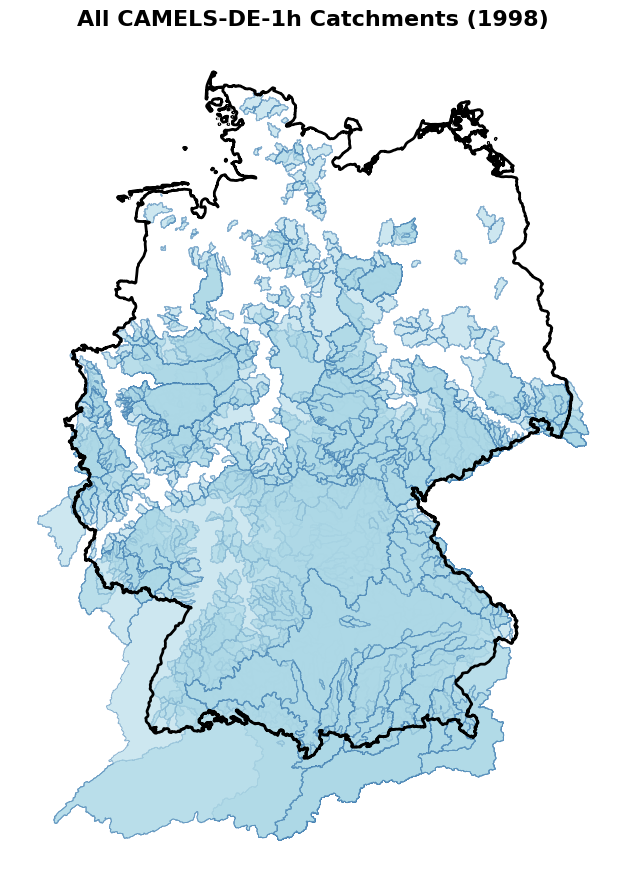

In [5]:
# get borders of Germany
germany_borders = gpd.read_file("/home/alexd/Projekte/CAMELS/Github/camels_catchments/merit_hydro/input_data/assets_criteria/vg250_01-01.utm32s.gpkg.ebenen/vg250_ebenen_0101/DE_VG250.gpkg")

# use only exterior borders
germany_borders = gpd.GeoDataFrame(geometry=[germany_borders.geometry.unary_union], crs=germany_borders.crs)

# set same crs
germany_borders = germany_borders.to_crs(gdf.crs)

# plot catchments and borders
fig, ax = plt.subplots(figsize=(7, 9))

# Plot catchments
gdf.plot(ax=ax, color="lightblue", edgecolor="steelblue", alpha=0.6, linewidth=0.6)

# Plot Germany borders on top
germany_borders.plot(ax=ax, color="none", edgecolor="black", linewidth=2)

# Add title
ax.set_title(f"All CAMELS-DE-1h Catchments ({len(gdf)})", fontsize=16, fontweight='bold')

# Remove all spines
ax.axis("off")

# Remove axis ticks and labels
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

## Add `in_camels_de1d` and `area_calc` to metadata

In [ ]:
if not PLOT_ONLY:
    # add the columns in_camels_de1d and area_calc to metadata
    # Merge area_calc to metadata
    meta1h = meta1h.merge(
        gdf[["gauge_id", "area_calc", "in_camelsde_1d", "diff_to_reported_area"]], 
        on="gauge_id", 
        how="left"
    )

    meta1h

,gauge_id,provider_id,gauge_name,waterbody_name,federal_state,lon,lat,easting,northing,elev_metadata,area_metadata,part_of_camelsp,area_calc_x,in_camelsde_1d_x,area_pct_in_germany,q_years,w_years,area_calc_y,in_camelsde_1d_y,diff_to_reported_area
0,DE110000,105,Kirchen-Hausen,Donau,Baden-Württemberg,8.679586,47.925507,4.222273e+06,2.757761e+06,657.334,758.528,True,763.066361,True,100.0,24.00,24.0,763.066361,True,0.598312
1,DE110010,106,Möhringen,Donau,Baden-Württemberg,8.760112,47.948961,4.228336e+06,2.760263e+06,649.162,826.963,True,831.294102,True,100.0,23.16,24.0,831.294102,True,0.523736
2,DE110020,120,Hundersingen,Donau,Baden-Württemberg,9.396100,48.072462,4.275974e+06,2.773394e+06,542.530,2621.324,True,2618.597245,True,100.0,24.00,24.0,2618.597245,True,-0.104022
3,DE110030,125,Berg,Donau,Baden-Württemberg,9.731457,48.266270,4.301054e+06,2.794786e+06,489.903,4072.790,True,4093.963291,True,100.0,24.00,24.0,4093.963291,True,0.519872
4,DE110040,129,Achstetten,Baierzer Rot,Baden-Württemberg,9.900817,48.263440,4.313633e+06,2.794441e+06,489.317,264.393,True,272.811527,True,100.0,24.00,24.0,272.811527,True,3.184096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2009,DEG11350,577340,Hohenleuben (ZP),Leuba,Thüringen,12.076081,50.703843,4.467645e+06,3.067877e+06,305.536,28.200,False,28.552454,False,100.0,11.92,0.0,28.552454,False,1.249837
2010,DEG11360,577342,Hohenleuben (AP),Leuba,Thüringen,12.068883,50.724615,4.467072e+06,3.070172e+06,279.136,41.400,False,42.110346,False,100.0,8.84,0.0,42.110346,False,1.715811
2011,DEG11370,577343,Hohenölsen,Ölsengrund,Thüringen,12.067612,50.725548,4.466979e+06,3.070273e+06,280.546,3.600,False,45.999463,False,100.0,12.00,0.0,45.999463,False,1177.762847
2012,DEG11380,577350,Weida-Heinoldsmühle,Auma,Thüringen,12.015941,50.768096,4.463203e+06,3.074903e+06,271.878,106.900,False,106.789596,False,100.0,12.00,0.0,106.789596,False,0.103277


## Percentage of catchment inside Germany

In [7]:
if not PLOT_ONLY:
    germany_borders = germany_borders.to_crs(gdf.crs)

    # Calculate intersection of each catchment with Germany
    gdf["geometry_intersection"] = gdf.geometry.intersection(germany_borders.geometry.iloc[0])

    # Calculate areas
    gdf["area_total"] = gdf.geometry.area
    gdf["area_in_germany"] = gdf["geometry_intersection"].area

    # Calculate percentage
    gdf["area_pct_in_germany"] = (gdf["area_in_germany"] / gdf["area_total"]) * 100
    gdf["area_pct_in_germany"] = gdf["area_pct_in_germany"].round(3)

    # Drop the temporary geometry_intersection column
    gdf = gdf.drop(columns=["geometry_intersection"])

    # Merge area_pct_in_germany to metadata
    meta1h = meta1h.merge(
        gdf[["gauge_id", "area_pct_in_germany"]], 
        on="gauge_id", 
        how="left"
    )
else:
    gdf = gdf.merge(
        meta1h[["gauge_id", "area_pct_in_germany"]],
        on="gauge_id",
        how="left"
    )

In [6]:
from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt

@interact(min_pct=IntSlider(min=0, max=100, step=5, value=0, description='Min %:', style={'description_width': '60px'}, layout={'width': '500px'}))
def plot_catchments(min_pct=0):
    gdf_filtered = gdf[gdf["area_pct_in_germany"] >= min_pct]
    
    fig, ax = plt.subplots(figsize=(8, 9))
    
    gdf_filtered.plot(column="area_pct_in_germany",
                     edgecolor="black",
                     cmap="RdYlGn",
                     legend=True,
                     alpha=0.5,
                     vmin=min_pct,
                     vmax=100,
                     legend_kwds={'label': "Area in Germany (%)", 'orientation': "vertical", 'shrink': 0.5},
                     ax=ax)
    
    germany_borders.boundary.plot(ax=ax, color="black", linewidth=2)
    
    ax.set_title(f"Catchments with ≥{min_pct}% in Germany (n={len(gdf_filtered)})")
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=0, description='Min %:', layout=Layout(width='500px'), step=5, style=Sli…

## Calculate Q and W years available for all stations

Only from `2001-01-01 01:00:00` to `2025-01-01 00:00:00` (Radklim available -> period we will cover in CAMELS-DE-1h)

In [ ]:
if not PLOT_ONLY:
    ids = meta1h["gauge_id"].values

    for id in tqdm(ids):
        station = Station1h(id)

        # read data with polars
        df = pl.read_csv(station.output_path / f"{id}_data.csv", try_parse_dates=True, dtypes={"discharge_vol_obs": pl.Float64, "water_level_obs": pl.Float64})

        # Filter to the time range (add UTC timezone to match the data)
        df_filtered = df.filter(
            (pl.col("date") >= pl.datetime(2001, 1, 1, 1, 0, 0, time_zone="UTC")) &
            (pl.col("date") < pl.datetime(2025, 1, 1, 0, 0, 0, time_zone="UTC"))
        )

        # Count non-null observations and convert to years (assuming hourly data)
        discharge_hours = df_filtered.filter(pl.col("discharge_vol_obs").is_not_null()).height
        discharge_years = discharge_hours / (365.25 * 24)

        water_level_hours = df_filtered.filter(pl.col("water_level_obs").is_not_null()).height
        water_level_years = water_level_hours / (365.25 * 24)

        meta1h.loc[meta1h["gauge_id"] == id, "q_years"] = round(discharge_years, 2)
        meta1h.loc[meta1h["gauge_id"] == id, "w_years"] = round(water_level_years, 2)

100%|██████████| 2014/2014 [11:16<00:00,  2.98it/s]


In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Create subplots
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[f'Discharge (n={meta1h["q_years"].notna().sum()})', 
                    f'Water Level (n={meta1h["w_years"].notna().sum()})']
)

# Define colors
colors = ['#2E86AB', '#A23B72']
titles = ['q_years', 'w_years']

for i, (col, color) in enumerate(zip(titles, colors), start=1):
    data = meta1h[col].dropna()
    
    # Add histogram
    fig.add_trace(
        go.Histogram(
            x=data,
            nbinsx=25,
            marker=dict(color=color, opacity=0.6, line=dict(color='white', width=1.2)),
            name=col.replace('_', ' ').title(),
            showlegend=False
        ),
        row=1, col=i
    )
    
    # Add median line
    median_val = data.median()
    fig.add_vline(
        x=median_val,
        line=dict(color='darkred', dash='dash', width=2),
        row=1, col=i,
        annotation=dict(
            text=f'Median: {median_val:.1f} yr',
            font=dict(size=10, color='darkred'),
            showarrow=False,
            xanchor='left',
            yanchor='top',
            x=median_val + 0.5,
            y=1.0,
            yref='paper'
        )
    )

# Update layout
fig.update_xaxes(title_text='Years Available (2001-2024)', row=1, col=1)
fig.update_xaxes(title_text='Years Available (2001-2024)', row=1, col=2)
fig.update_yaxes(title_text='Count', row=1, col=1)
fig.update_yaxes(title_text='Count', row=1, col=2)

fig.update_layout(
    height=450,
    width=1200,
    showlegend=False,
    plot_bgcolor='white',
    font=dict(size=11),
    title_font=dict(size=12, family='Arial, sans-serif'),
    margin=dict(t=50, b=50, l=50, r=50)
)

# Update axes styling
fig.update_xaxes(showgrid=False, showline=True, linewidth=1, linecolor='black')
fig.update_yaxes(showgrid=True, gridwidth=0.7, gridcolor='lightgray', showline=True, linewidth=1, linecolor='black')

fig.show()

## Save updated metadata

In [ ]:
if not PLOT_ONLY:
    meta1h.to_csv("../output_data/metadata1h.csv", index=False)

## Make example selection of catchmentes based on criteria

In [11]:
MAX_AREA_DIFF = 20  # maximum allowed difference between calculated MERIT Hydro area and metadata area in percent
MIN_AREA_PCT_IN_GERMANY = 90  # minimum percentage of catchment area that must lie within Germany
MIN_Q_YEARS = 1  # minimum years of discharge data available
MIN_AREA = 1  # minimum catchment area in km²
MAX_AREA = 30000  # maximum catchment area in km²

selected_catchments = meta1h[
    (meta1h["diff_to_reported_area"].abs() <= MAX_AREA_DIFF) &
    (meta1h["area_pct_in_germany"] >= MIN_AREA_PCT_IN_GERMANY) &
    (meta1h["q_years"] >= MIN_Q_YEARS) &
    (meta1h["area_calc"] >= MIN_AREA) &
    (meta1h["area_calc"] <= MAX_AREA)
]

selected_catchments

,gauge_id,provider_id,gauge_name,waterbody_name,federal_state,lon,lat,easting,northing,elev_metadata,area_metadata,part_of_camelsp,area_calc,in_camelsde_1d,area_pct_in_germany,q_years,w_years,diff_to_reported_area
0,DE110000,105,Kirchen-Hausen,Donau,Baden-Württemberg,8.679586,47.925507,4.222273e+06,2.757761e+06,657.334,758.528,True,763.066361,True,100.0,24.00,24.0,0.598312
1,DE110010,106,Möhringen,Donau,Baden-Württemberg,8.760112,47.948961,4.228336e+06,2.760263e+06,649.162,826.963,True,831.294102,True,100.0,23.16,24.0,0.523736
2,DE110020,120,Hundersingen,Donau,Baden-Württemberg,9.396100,48.072462,4.275974e+06,2.773394e+06,542.530,2621.324,True,2618.597245,True,100.0,24.00,24.0,-0.104022
3,DE110030,125,Berg,Donau,Baden-Württemberg,9.731457,48.266270,4.301054e+06,2.794786e+06,489.903,4072.790,True,4093.963291,True,100.0,24.00,24.0,0.519872
4,DE110040,129,Achstetten,Baierzer Rot,Baden-Württemberg,9.900817,48.263440,4.313633e+06,2.794441e+06,489.317,264.393,True,272.811527,True,100.0,24.00,24.0,3.184096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2008,DEG11340,577310,Staitz (AP),Weida,Thüringen,12.002473,50.707509,4.462436e+06,3.068139e+06,287.191,165.000,False,166.177402,False,100.0,12.00,0.0,0.713577
2009,DEG11350,577340,Hohenleuben (ZP),Leuba,Thüringen,12.076081,50.703843,4.467645e+06,3.067877e+06,305.536,28.200,False,28.552454,False,100.0,11.92,0.0,1.249837
2010,DEG11360,577342,Hohenleuben (AP),Leuba,Thüringen,12.068883,50.724615,4.467072e+06,3.070172e+06,279.136,41.400,False,42.110346,False,100.0,8.84,0.0,1.715811
2012,DEG11380,577350,Weida-Heinoldsmühle,Auma,Thüringen,12.015941,50.768096,4.463203e+06,3.074903e+06,271.878,106.900,False,106.789596,False,100.0,12.00,0.0,0.103277


In [ ]:
from ipywidgets import interact, IntSlider, FloatSlider
import ipywidgets as widgets
import matplotlib.pyplot as plt

@interact(
    max_area_diff=IntSlider(min=0, max=100, step=5, value=20, 
                            description='Max Area Diff (%):', 
                            style={'description_width': '150px'}, 
                            layout={'width': '500px'}),
    min_area_pct=IntSlider(min=0, max=100, step=5, value=90, 
                           description='Min Area in DE (%):', 
                           style={'description_width': '150px'}, 
                           layout={'width': '500px'}),
    min_q_years=FloatSlider(min=0, max=24, step=0.5, value=1, 
                           description='Min Q Years:', 
                           style={'description_width': '150px'}, 
                           layout={'width': '500px'}),
    min_area=FloatSlider(min=0, max=100, step=1, value=0,
                           description='Min Area (km²):',
                           style={'description_width': '150px'},
                           layout={'width': '500px'}),
    max_area=FloatSlider(min=0, max=50000, step=100, value=50000,
                           description='Max Area (km²):',
                           style={'description_width': '150px'},
                           layout={'width': '500px'}),
)
def filter_catchments(max_area_diff=20, min_area_pct=90, min_q_years=1, min_area=0, max_area=50000):
    selected = meta1h[
        (meta1h["diff_to_reported_area"].abs() <= max_area_diff) &
        (meta1h["area_pct_in_germany"] >= min_area_pct) &
        (meta1h["q_years"] >= min_q_years) &
        (meta1h["area_calc"] >= min_area) &
        (meta1h["area_calc"] <= max_area)
    ]
    
    # Print summary statistics
    print(f"{'='*60}")
    print(f"SELECTION CRITERIA:")
    print(f"  • Max Area Difference: ≤ {max_area_diff}%")
    print(f"  • Min Area in Germany: ≥ {min_area_pct}%")
    print(f"  • Min Q Years: ≥ {min_q_years}")
    print(f"{'='*60}")
    print(f"RESULTS:")
    print(f"  • Selected Catchments: {len(selected)} / {len(meta1h)} ({len(selected)/len(meta1h)*100:.1f}%)")
    print(f"  • In CAMELS-DE-1d: {selected['in_camelsde_1d'].sum()} ({selected['in_camelsde_1d'].sum()/len(selected)*100:.1f}%)")
    print(f"  • Median Q Years: {selected['q_years'].median():.2f}")
    print(f"  • Median W Years: {selected['w_years'].median():.2f}")
    print(f"  • Median Area: {selected['area_calc'].median():.1f} km²")
    print(f"  • Max Area: {selected['area_calc'].max():.1f} km²")
    print(f"{'='*60}\n")
    
    # Get selected catchments from gdf
    selected_gdf = gdf[gdf['gauge_id'].isin(selected['gauge_id'])]
    
    # Create map
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # Plot all catchments in light gray (background)
    gdf.plot(ax=ax, color='lightgray', edgecolor='gray', alpha=0.3, linewidth=0.5)
    
    # Plot selected catchments on top
    selected_gdf.plot(ax=ax, color='steelblue', edgecolor='darkblue', alpha=0.4, linewidth=0.8)
    
    # Plot Germany borders
    germany_borders.plot(ax=ax, color='none', edgecolor='black', linewidth=2)
    
    # Add title
    ax.set_title(f'Selected Catchments (n={len(selected_gdf)})', fontsize=14, fontweight='bold')
    
    # Remove axes
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    #return selected

# To get the filtered dataframe:
# selected_catchments = filter_catchments(max_area_diff=20, min_area_pct=90, min_q_years=1)

interactive(children=(IntSlider(value=20, description='Max Area Diff (%):', layout=Layout(width='500px'), step…